## Importy

In [1]:
include("auto_differ.jl")
using .auto_differ
using MLDatasets
using Statistics
using Random
using Plots

### Dataset

In [2]:
train_data = MLDatasets.FashionMNIST(split=:train)
test_data  = MLDatasets.FashionMNIST(split=:test)

function loader(data; limit::Int=0)
    n = limit > 0 ? limit : length(data.targets)
    
    x4dim = reshape(Float32.(data.features[:, :, 1:n]), 28, 28, 1, n)
    
    yhot = zeros(Float32, 10, n)
    for i in 1:n
        yhot[data.targets[i] + 1, i] = 1.0f0
    end
    
    return x4dim, yhot
end

train_x, train_y = loader(train_data; limit=60000)
test_x, test_y   = loader(test_data; limit=10000)

(Float32[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;;; … ;;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Float32[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 1.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 1.0 0.0 … 0.0 0.0])

### Architektura sieci

In [3]:
net = Chain(
    Conv((3, 3), 1 => 6, pad=1),
    MaxPool((2, 2)),
    Conv((3, 3), 6 => 16, pad=1),
    MaxPool((2, 2)),
    Flatten(),
    Dense(784 => 84, :relu),
    Dropout(0.4f0),
    Dense(84 => 10)
)

graph, input_node, target_node, out_node, loss_node = build_model(net, (28, 28, 1), (10,));

In [4]:
function loss_and_accuracy(graph, in_node, tgt_node, out_node, loss_node, x_data, y_data)
    set_training!(false)
    loss_sum = 0.0f0
    correct = 0
    n = size(x_data, 4)
    
    for i in 1:n
        forward!(graph, in_node => x_data[:, :, 1:1, i], tgt_node => y_data[:, i])
        loss_sum += loss_node.data[1]
        if argmax(out_node.data) == argmax(y_data[:, i])
            correct += 1
        end
    end
    
    loss = loss_sum / n
    acc = round(100 * correct / n; digits=2)
    return (; loss, acc)
end

@show loss_and_accuracy(graph, input_node, target_node, out_node, loss_node, test_x, test_y);

train_log = []
settings = (;
    eta = 0.01f0,
    epochs = 3,
    batchsize = 10,
)

loss_and_accuracy(graph, input_node, target_node, out_node, loss_node, test_x, test_y) = (loss = 2.35802f0, acc = 8.57)


(eta = 0.01f0, epochs = 3, batchsize = 10)

### Uczenie

In [5]:
accuracy = zeros(settings.epochs, 2)

for epoch in 1:settings.epochs
    set_training!(true)
    idxs = randperm(size(train_x, 4))
    
    zerograd!(graph)
    
    @time for (step, i) in enumerate(idxs)
        
        for n in graph; !n.trainable && fill!(n.grad, 0.0f0); end
        
        forward!(graph, input_node => train_x[:,:,1:1,i], target_node => train_y[:,i])
        backward!(graph)
        
        if step % settings.batchsize == 0 || step == length(idxs)
            for n in graph; n.trainable && (n.grad ./= settings.batchsize); end
            optimize!(graph, settings.eta)
            zerograd!(graph)
        end
    end
    
    # Obliczanie metryk
    train_metrics = loss_and_accuracy(graph, input_node, target_node, out_node, loss_node, train_x, train_y)
    test_metrics  = loss_and_accuracy(graph, input_node, target_node, out_node, loss_node, test_x, test_y)
    
    @info epoch acc=train_metrics.acc test_acc=test_metrics.acc
    
    nt = (; epoch, loss=train_metrics.loss, acc=train_metrics.acc, test_loss=test_metrics.loss, test_acc=test_metrics.acc)
    push!(train_log, nt)
    accuracy[epoch, 1] = train_metrics.acc
    accuracy[epoch, 2] = test_metrics.acc
end

 69.153938 seconds (98.36 M allocations: 4.358 GiB, 1.71% gc time, 8.07% compilation time)


┌ Info: 1
│   acc = 85.99
│   test_acc = 84.87
└ @ Main c:\Users\rafal\vsProjects\AwID_project\AwID-library\src\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X11sZmlsZQ==.jl:27


 63.401944 seconds (93.75 M allocations: 4.140 GiB, 1.64% gc time)


┌ Info: 2
│   acc = 86.66
│   test_acc = 85.34
└ @ Main c:\Users\rafal\vsProjects\AwID_project\AwID-library\src\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X11sZmlsZQ==.jl:27


 64.015901 seconds (93.75 M allocations: 4.140 GiB, 1.41% gc time)


┌ Info: 3
│   acc = 89.03
│   test_acc = 87.62
└ @ Main c:\Users\rafal\vsProjects\AwID_project\AwID-library\src\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X11sZmlsZQ==.jl:27


In [8]:
n_probek = 50
set_training!(false)

d = [argmax(test_y[:, i]) - 1 for i in 1:n_probek]
y = Int[]

for i in 1:n_probek
    img = test_x[:, :, 1:1, i]
    forward!(graph, input_node => img)
    push!(y, argmax(out_node.data) - 1) 
end

println("Wyniki testu (Przewidziane | Prawdziwe):")
display(hcat(y, d))

50×2 Matrix{Int64}:
 9  9
 2  2
 1  1
 1  1
 6  6
 1  1
 4  4
 6  6
 5  5
 7  7
 ⋮  
 1  1
 0  3
 7  7
 6  6
 7  7
 2  2
 1  1
 2  2
 6  2

Wyniki testu (Przewidziane | Prawdziwe):


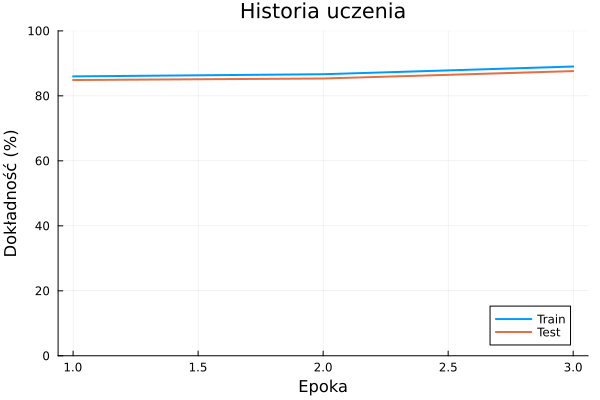

In [9]:
epoki = 1:settings.epochs

p = plot(epoki, accuracy[:, 1], 
         label="Train", 
         linewidth=2, 
         xlabel="Epoka", 
         ylabel="Dokładność (%)", 
         ylims=(0, 100),
         legend=:bottomright,
         title="Historia uczenia")

plot!(p, epoki, accuracy[:, 2], 
      label="Test", 
      linewidth=2)

display(p)